# Evaluate a golden codec on your own data

Score a published **compressionKIT** codec on signals **you** provide — either
your own recordings or the built-in synthetic generators (no dataset needed).

The flow is the same regardless of source:

1. Load a codec.
2. Get a 1-D signal sampled at `codec.sample_rate` Hz.
3. Split into `codec.frame_size` frames, round-trip, and aggregate metrics.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from compressionkit.evaluation.metrics import compute_signal_metrics
from compressionkit.runtime import load_codec
from compressionkit.synthetic import add_noise, ecg_mcsharry, ppg_dynamical

# "-v1.0" repos are the current release track. Uncomment any line below to
# try a different modality/compression ratio or codec family (RVQ = learned/AI,
# SPIHT = DSP-only wavelet codec, hybrid = learned denoiser + SPIHT). All three
# families implement the same Codec interface, so nothing below needs to change.
CODEC_SOURCE = "Ambiq/compressionkit-ppg-4x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ppg-2x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ppg-8x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ppg-16x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ppg-32x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ecg-2x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ecg-4x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ecg-8x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ecg-16x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ecg-32x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ecg-64x-v1.0"
# SPIHT (DSP-only, no trained weights) and hybrid (learned denoiser + SPIHT):
# CODEC_SOURCE = "Ambiq/compressionkit-ppg-spiht-4x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ppg-hybrid-4x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ecg-spiht-4x-v1.0"
# CODEC_SOURCE = "Ambiq/compressionkit-ecg-hybrid-4x-v1.0"
# CODEC_SOURCE = "results/ppg_rvq_64hz_04x_golden/deploy"  # local, offline

codec = load_codec(CODEC_SOURCE)
fs, n = codec.sample_rate, codec.frame_size
print(f"{codec.name}  ({codec.modality}, {fs} Hz, {n}-sample frames)")


Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 14328.07it/s]

ppg_rvq_64hz_04x_golden  (ppg, 64 Hz, 320-sample frames)


## Option A — synthetic signal (runs anywhere)

The analytical generators produce a clean, ground-truth waveform at the codec's
sample rate. Add calibrated noise to mimic real wearables.

In [11]:
duration_s = 60.0
if codec.modality == "ecg":
    clean = ecg_mcsharry(duration_s=duration_s, sample_rate=float(fs), hr_mean=60.0)
else:
    clean = ppg_dynamical(duration_s=duration_s, sample_rate=float(fs), hr_mean=72.0)

# Optional: add noise at a single target SNR to stress-test the codec.
# For a sweep across several noise levels at once, see the "Robustness"
# section below instead.
# clean, _ = add_noise(clean, sample_rate=float(fs), snr_db=15.0)

signal = clean.astype("float32")
print(f"signal: {signal.shape[0]} samples ({signal.shape[0] / fs:.1f} s)")

signal: 3840 samples (60.0 s)


## Option B — bring your own data

Provide a 1-D float32 array sampled at `codec.sample_rate` Hz (resample first if
your sensor runs at a different rate). Uncomment to use it instead of the
synthetic signal above.

In [ ]:
# signal = np.load("my_recording.npy").astype("float32")
# assert signal.ndim == 1, "expects a 1-D signal at codec.sample_rate Hz"
#
# If your data is at a different rate, resample to codec.sample_rate first:
# from scipy.signal import resample_poly
# signal = resample_poly(signal, fs, native_fs).astype("float32")

## Frame, round-trip, and score

In [12]:
def to_frames(sig: np.ndarray, frame_size: int) -> np.ndarray:
    """Split a 1-D signal into non-overlapping (n_frames, frame_size) frames."""
    usable = (len(sig) // frame_size) * frame_size
    return sig[:usable].reshape(-1, frame_size)


frames = to_frames(signal, n)
rows, recon_frames = [], []
for i, f in enumerate(frames):
    enc = codec.compress(f)
    rec = codec.decompress(enc)
    recon_frames.append(rec)
    mm = compute_signal_metrics(f, rec)
    rows.append({
        "frame": i,
        "bits": enc.nbits,
        "prd_percent": mm["prd_percent"],
        "cosine_similarity": mm["cosine_similarity"],
        "rmse": mm["rmse"],
    })

df = pd.DataFrame(rows)
recon = np.concatenate(recon_frames)
overall_cr = (frames.size * 32) / df["bits"].sum()  # vs 32-bit float baseline

print(f"frames     : {len(df)}")
print(f"overall CR : {overall_cr:.2f}x (vs 32-bit float)")
df[["prd_percent", "cosine_similarity", "rmse"]].describe().loc[["mean", "50%", "min", "max"]]

frames     : 12
overall CR : 4.00x (vs 32-bit float)


,prd_percent,cosine_similarity,rmse
mean,16.585491,0.987021,0.009096
50%,16.809828,0.986869,0.009187
min,12.790186,0.983588,0.008409
max,18.440839,0.991917,0.009915


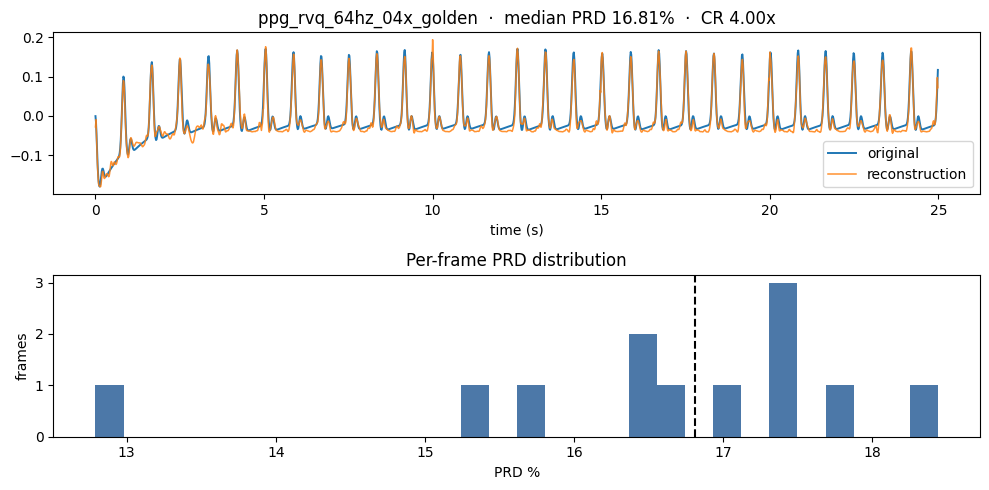

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5))

show = slice(0, min(5 * n, len(signal)))  # first ~5 frames
t = np.arange(len(recon))[show] / fs
ax[0].plot(t, signal[: len(recon)][show], label="original", lw=1.4)
ax[0].plot(t, recon[show], label="reconstruction", lw=1.1, alpha=0.85)
ax[0].set_title(f"{codec.name}  ·  median PRD {df['prd_percent'].median():.2f}%  ·  CR {overall_cr:.2f}x")
ax[0].set_xlabel("time (s)")
ax[0].legend()

ax[1].hist(df["prd_percent"], bins=30, color="#4C78A8")
ax[1].axvline(df["prd_percent"].median(), color="k", ls="--")
ax[1].set_xlabel("PRD %")
ax[1].set_ylabel("frames")
ax[1].set_title("Per-frame PRD distribution")

plt.tight_layout()
plt.show()

## Robustness: fidelity across noise levels

A single pass hides how the codec degrades as input quality drops. Sweep a
small SNR ladder using the same calibrated noise harness the golden models are
evaluated with, and edit `snr_levels_db` to add more/finer levels.

If you have **real recorded noise segments** (not synthetic), use
`compressionkit.evaluation.empirical_regime.add_empirical_noise(windows,
noise_bank, snr_db, seed=...)` instead — this is the literal empirical-noise
injection used by golden training/eval, but it requires your own `noise_bank`
array of real noise/residual segments.


In [14]:
snr_levels_db: list[float | None] = [None, 24, 18, 12, 6, 0]  # None = clean; add/remove levels freely

snr_rows = []
for snr_db in snr_levels_db:
    if snr_db is None:
        noisy_signal, label = signal, "clean"
    else:
        noisy_signal, _ = add_noise(signal, sample_rate=float(fs), snr_db=snr_db, seed=0)
        noisy_signal = noisy_signal.astype("float32")
        label = f"{snr_db:g} dB"

    noisy_frames = to_frames(noisy_signal, n)
    prd_vals = [compute_signal_metrics(f, codec.decompress(codec.compress(f)))["prd_percent"] for f in noisy_frames]
    snr_rows.append({"input": label, "median_prd_percent": float(np.median(prd_vals)), "frames": len(prd_vals)})

snr_df = pd.DataFrame(snr_rows)
snr_df


,input,median_prd_percent,frames
0,clean,16.809828,12
1,24 dB,17.206760,12
2,18 dB,18.011693,12
3,12 dB,22.661638,12
4,6 dB,33.776077,12
5,0 dB,49.759792,12


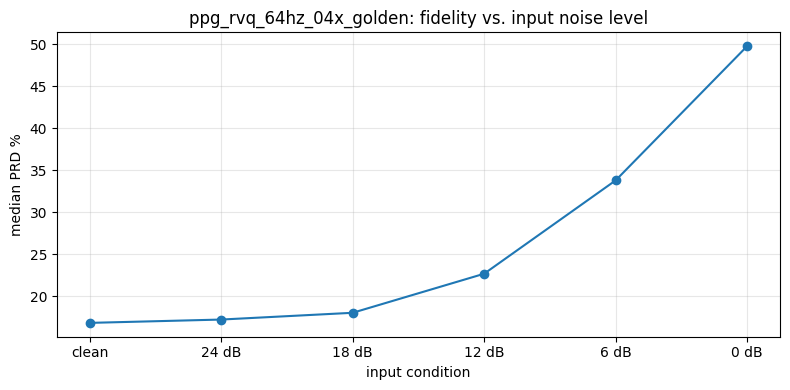

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(snr_df)), snr_df["median_prd_percent"], marker="o")
plt.xticks(range(len(snr_df)), snr_df["input"])
plt.xlabel("input condition")
plt.ylabel("median PRD %")
plt.title(f"{codec.name}: fidelity vs. input noise level")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Next steps

- Compare available tiers on the same signal to pick a CR/fidelity operating point.
- Extend the noise sweep above with more levels, or plug in real recorded noise via `add_empirical_noise`.
- Set up real datasets via the [Dataset Setup](https://ambiqai.github.io/compressionkit/datasets/) guide for population-scale evaluation.